In [55]:
#Importing all necesary library:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import statsmodels.api as sm 
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.metrics import *
from scipy import stats
warnings.filterwarnings('ignore')

#Set plotting style:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

**1.) Data Preparation and EDA**
- 

In [56]:
#Load the dataset:
df = fetch_openml('adult', version = 2, as_frame = True)
df = df.frame
df.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [57]:
#Check dataframe shape:
df_shape = df.shape

print("Total number of rows:", df_shape[0])
print("Total number of columns", df_shape[1])

Total number of rows: 48842
Total number of columns 15


In [58]:
#Dataset descriptive statistics:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


**Key Observations:**
- Presented above is the desrriptive statistics of the given dataframe.
- These are the following columns/features based from the given output that may have potential outliers:
  - age, capital-gain, capital-loss, hours-per-week, fnlwgt

In [59]:
#Dataset data types:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


**Key Observations:**
- The following presented above are the data types present in every column in the dataframe. 

In [60]:
#Check for null values:
num_null_col = df.isnull().sum()
num_null_row = df.isnull().any(axis=1).sum()
num_not_null_row = df.notnull().all(axis=1).sum()

print(num_null_col)
print("=" * 60)
print("Total number of rows that have no null value:", num_not_null_row)
print("Total number of rows that atleast 1 null value:", num_null_row)

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64
Total number of rows that have no null value: 45222
Total number of rows that atleast 1 null value: 3620


**Key Observation:**
- Presented above are the total counts of null values for both row and column. 

In [61]:
#Handling missing values:
df_clean = df.dropna()
num_null_col = df_clean.isnull().sum()
num_null_row = df_clean.isnull().any(axis=1).sum()
num_not_null_row = df_clean.notnull().all(axis=1).sum()
total_rows = df.shape[0]
remaining_rows = df_clean.shape[0]
data_loss_percent = ((total_rows - remaining_rows) / total_rows) * 100

print(num_null_col)
print("=" * 60)
print("Total number of rows that have no null value:", num_not_null_row)
print("Total number of rows that atleast 1 null value:", num_null_row)
print("Data loss after dropping all rows with null values:", f"{data_loss_percent:.2f}","%")

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
class             0
dtype: int64
Total number of rows that have no null value: 45222
Total number of rows that atleast 1 null value: 0
Data loss after dropping all rows with null values: 7.41 %


**Key Observation and Application:**
- We have removed all rows that have atleast 1 null value.
- The reasons why we remove such rows it is because it does not affect the entirety of the dataframe compared to the sheer number of data left that dont have any null values. In terms of data loss we have loss approximately 7% of our data. It may seem that it is not less than 5% which may some and also assumingly considered to be the safest amount in terms of data loss but due to the amount of data still left or existed after dropping rows that have null values still out weighs it in general. 

In [62]:
#Create target variable:
df_clean['high_income'] = (df_clean['class'] == '>50K').astype(int)
df_clean = df_clean.drop('class', axis = 1)
df_clean.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,high_income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0


**Key Application:**
- We have created a new column (target variable) called 'high_income'.
- The basis of the target variable is the feature or column 'class'.
  - If class is >50K = 1
  - Else, if class is =<50K = 0
- Dropped the basis of feature 'high_income' which is the 'class' feature.

In [63]:
#Group all columns that are categorical:
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_cols = ", ".join(categorical_cols)

print("Categorical columns:", categorical_cols)

Categorical columns: workclass, education, marital-status, occupation, relationship, race, sex, native-country


**Key Observation;**
- These are the following columns/features that are categorical variables that we must convert to dummy variables. 

In [64]:
#Convert categorical to dummy variables:
dum_WC = pd.get_dummies(df_clean['workclass'], prefix = "WC", drop_first = True).astype(int)
dum_EDUC = pd.get_dummies(df_clean['education'], prefix = "EDUC", drop_first = True).astype(int)
dum_MS = pd.get_dummies(df_clean['marital-status'], prefix = "MS", drop_first = True).astype(int)
dum_OCC = pd.get_dummies(df_clean['occupation'], prefix = "OCC", drop_first = True).astype(int)
dum_REL = pd.get_dummies(df_clean['relationship'], prefix = "REL", drop_first = True).astype(int)
dum_RCE = pd.get_dummies(df_clean['race'], prefix = "RCE", drop_first = True).astype(int)
dum_SX = pd.get_dummies(df_clean['sex'], prefix = "SX", drop_first = True).astype(int)
dum_NC = pd.get_dummies(df_clean['native-country'], prefix = "NC", drop_first = True).astype(int)
df_clean = pd.concat([df_clean, dum_WC, dum_EDUC, dum_MS, dum_OCC, dum_REL, dum_RCE, dum_SX, dum_NC], axis = 1)
df_clean.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,...,NC_Portugal,NC_Puerto-Rico,NC_Scotland,NC_South,NC_Taiwan,NC_Thailand,NC_Trinadad&Tobago,NC_United-States,NC_Vietnam,NC_Yugoslavia
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,...,0,0,0,0,0,0,0,1,0,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,...,0,0,0,0,0,0,0,1,0,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,...,0,0,0,0,0,0,0,1,0,0
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,...,0,0,0,0,0,0,0,1,0,0
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,...,0,0,0,0,0,0,0,1,0,0


**Key Application:**
- We have converted all categorical variables to dummy variables or columns where it only contains 1's and 0's.
- You may add prefixes to easily identify what dummy variable came from what column or feature. 

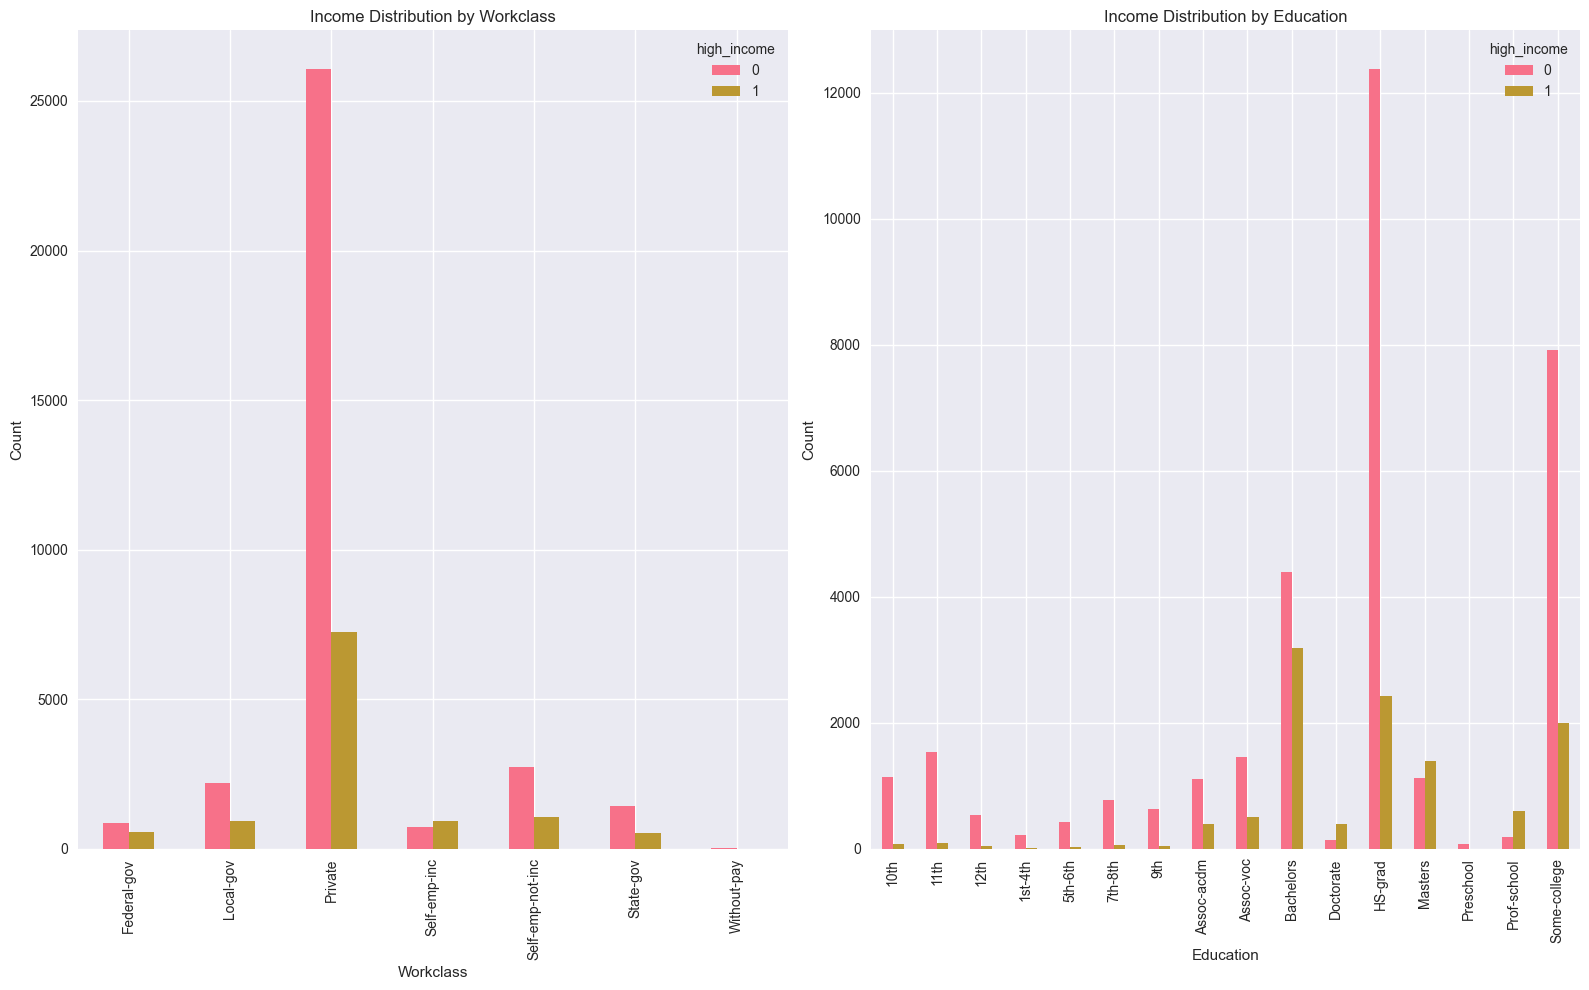

In [65]:
#Create basic plots for income distribution across all variables: Categorical Variables
fig, axes = plt.subplots(1, 2, figsize = (16, 10))

wc_inc_dist = pd.crosstab(df_clean['workclass'], df_clean['high_income'])
wc_inc_dist.plot(kind = 'bar', ax = axes[0])
axes[0].set_title("Income Distribution by Workclass")
axes[0].set_xlabel("Workclass")
axes[0].set_ylabel("Count")

educ_inc_dist = pd.crosstab(df_clean['education'], df_clean['high_income'])
educ_inc_dist.plot(kind = 'bar', ax = axes[1])
axes[1].set_title("Income Distribution by Education")
axes[1].set_xlabel("Education")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

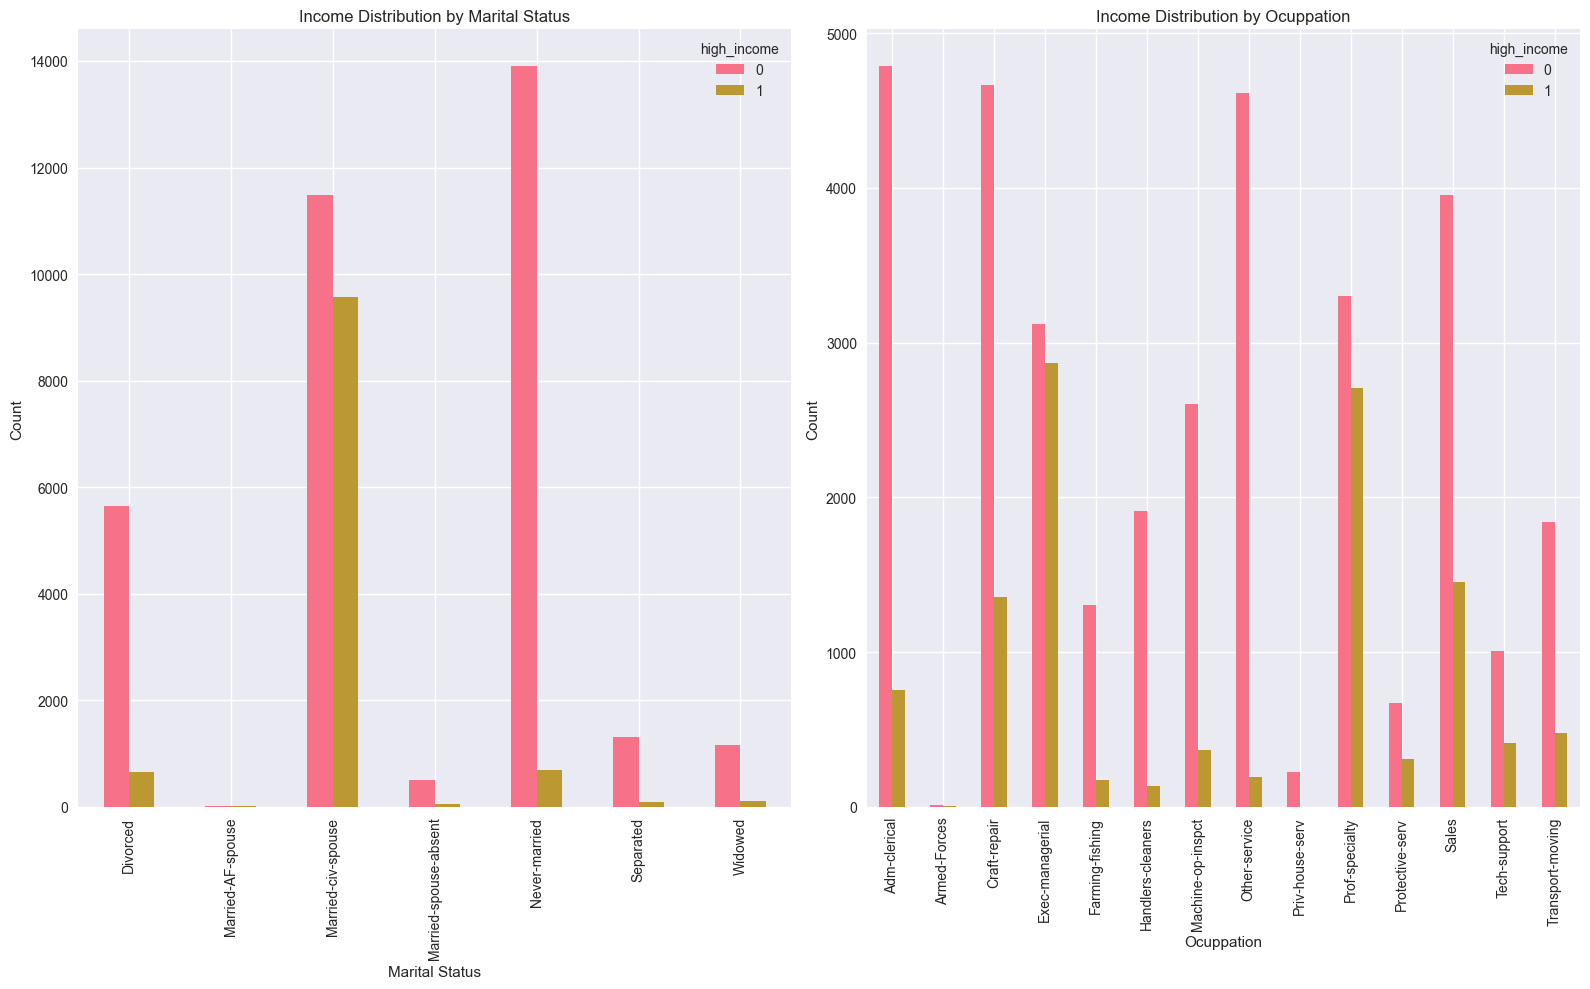

In [66]:
#Create basic plots for income distribution across all variables: Categorical Variables
fig, axes = plt.subplots(1, 2, figsize = (16, 10))

ms_inc_dist = pd.crosstab(df_clean['marital-status'], df_clean['high_income'])
ms_inc_dist.plot(kind = 'bar', ax = axes[0])
axes[0].set_title("Income Distribution by Marital Status")
axes[0].set_xlabel("Marital Status")
axes[0].set_ylabel("Count")

occ_inc_dist = pd.crosstab(df_clean['occupation'], df_clean['high_income'])
occ_inc_dist.plot(kind = 'bar', ax = axes[1])
axes[1].set_title("Income Distribution by Ocuppation")
axes[1].set_xlabel("Ocuppation")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

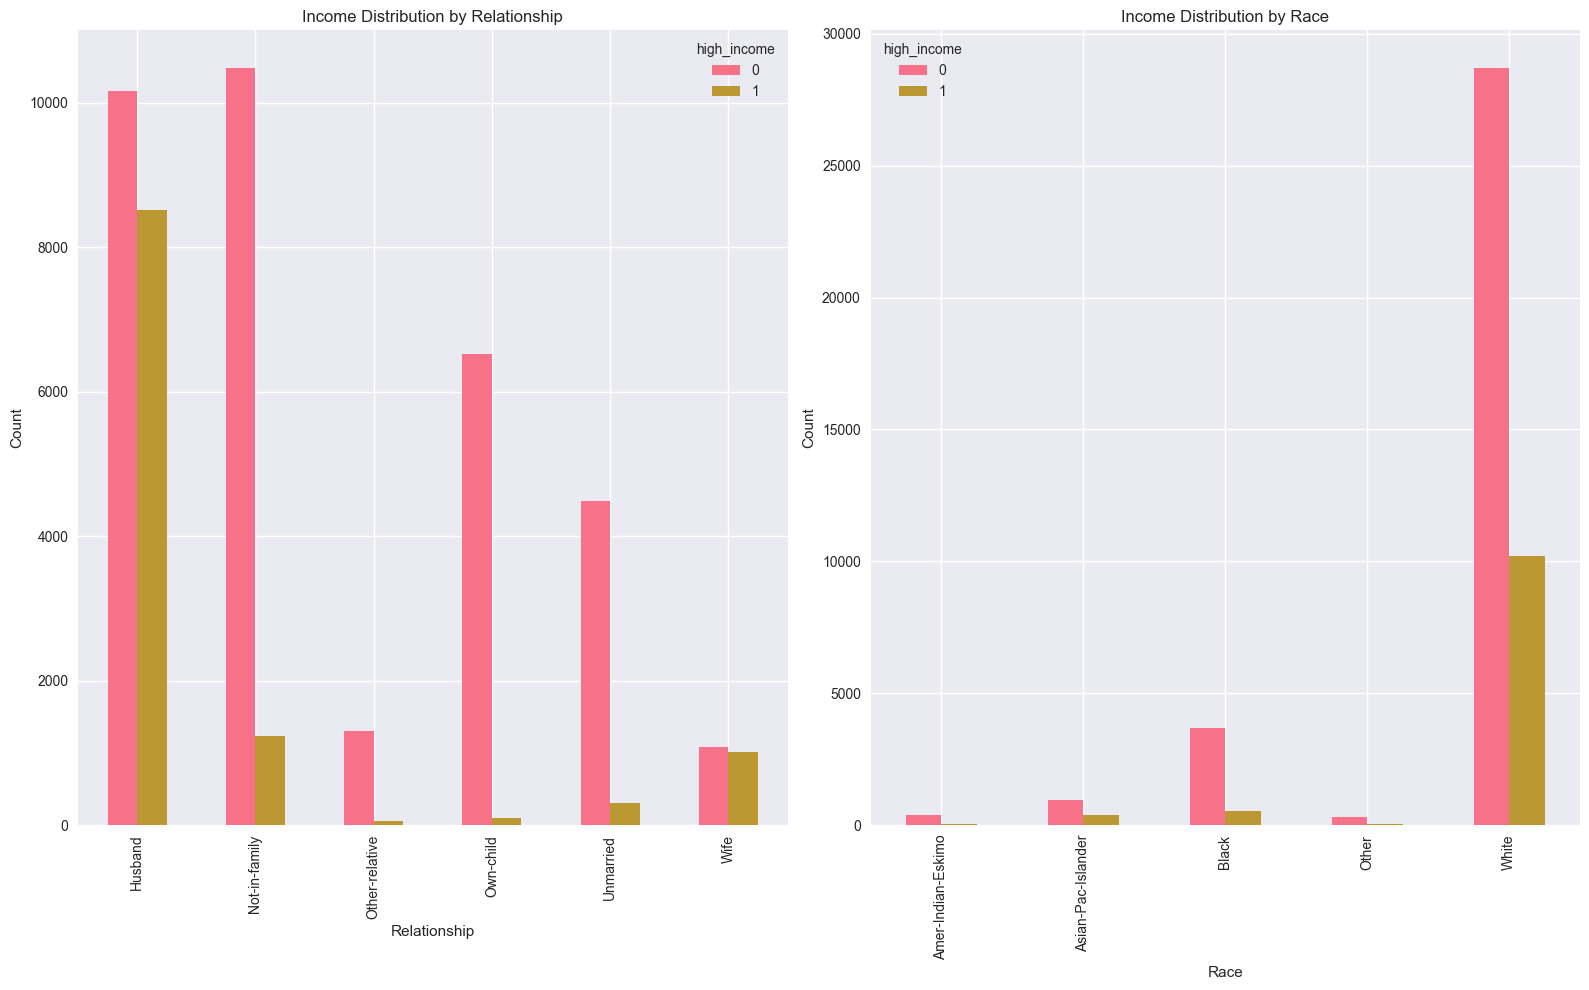

In [67]:
#Create basic plots for income distribution across all variables: Categorical Variables
fig, axes = plt.subplots(1, 2, figsize = (16, 10))

rel_inc_dist = pd.crosstab(df_clean['relationship'], df_clean['high_income'])
rel_inc_dist.plot(kind = 'bar', ax = axes[0])
axes[0].set_title("Income Distribution by Relationship")
axes[0].set_xlabel("Relationship")
axes[0].set_ylabel("Count")

rce_inc_dist = pd.crosstab(df_clean['race'], df_clean['high_income'])
rce_inc_dist.plot(kind = 'bar', ax = axes[1])
axes[1].set_title("Income Distribution by Race")
axes[1].set_xlabel("Race")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

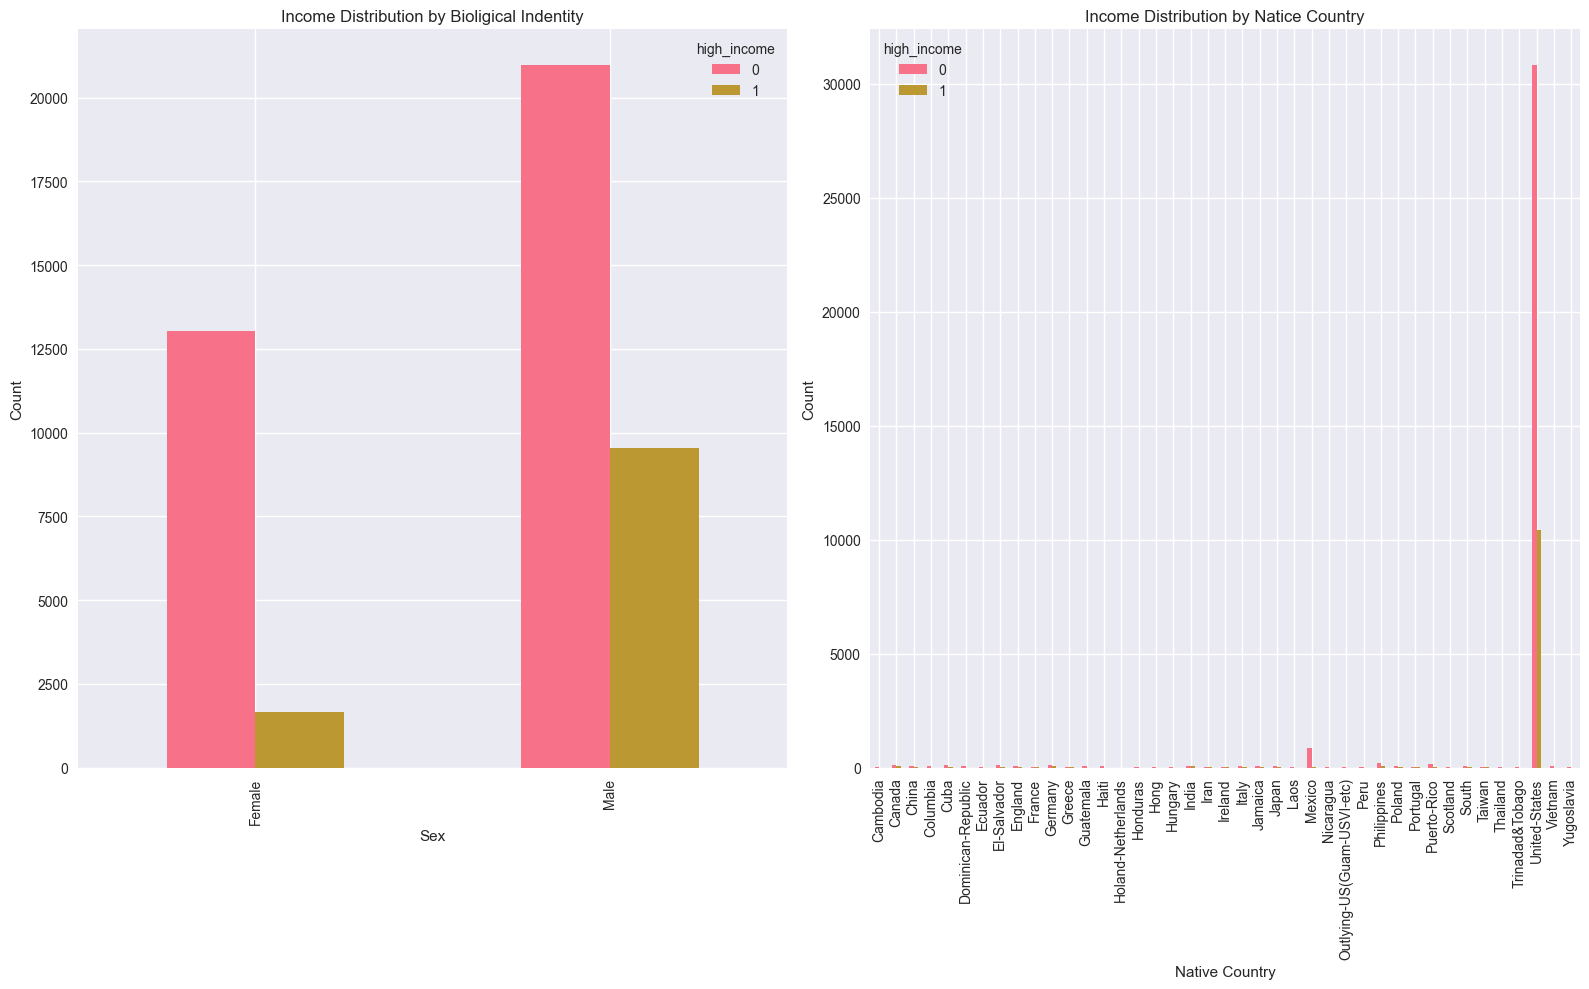

In [68]:
#Create basic plots for income distribution across all variables: Categorical Variables
fig, axes = plt.subplots(1, 2, figsize = (16, 10))

wc_inc_dist = pd.crosstab(df_clean['sex'], df_clean['high_income'])
wc_inc_dist.plot(kind = 'bar', ax = axes[0])
axes[0].set_title("Income Distribution by Bioligical Indentity")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Count")

educ_inc_dist = pd.crosstab(df_clean['native-country'], df_clean['high_income'])
educ_inc_dist.plot(kind = 'bar', ax = axes[1])
axes[1].set_title("Income Distribution by Natice Country")
axes[1].set_xlabel("Native Country")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

**Key Observation:**
- **Income Distribution by Workclass:**
  - Private work class dominates both low and high income counts.
  - State government has the fewest low income individuals.
  - Self employed incorporated has the fewest high income individuals.
- **Income Distribution by Education:**
  - HS graduate has the highest count of low income individuals.
  - Bachelor’s degree has the highest count of high income individuals.
- **Income Distributuion by Marital Statues:**
  - Never-married marital status has the highest count of low income counts.
  - Married-city-spouse marital status has the highest count of high income counts.
  - Married-AF-spuse marital status both have the lowest counf of high and low income counts.
- **Income Distribution by Occupation:**
  - Adm-clerical occupation has the highest count of low income counts.
  - Exec-manegerial occupation has the highest count of high income counts.
  - Armed-forces occupation has the both lowest count of low and high income counts.
- **Income Distribution by Relationship:**
  - Not-in-family relationship has the heighest count of low income counts.
  - Husband relationship has the highest count of high income counts.
  - Wife relationship has the lowest count of low income counts.
  - Other relative relationship has the lowest count of high income counts.
- **Income Distribution by Race:**
  - White race has the highest count of low income and high income counts.
  - Amer-Indian-Eskimo and Other race both have the lowest low income count.
  - Other race has the lowest count of high income count.
- **Income Distribution by Biological Identity (Sex):**
  - Male individuals has both the highest count for low and high income count.
  - Female individuals has both the lowest count for low and high income count.
- **Income Distribution by Native Country:**
  - United States has both the highest count for for low and high income count.

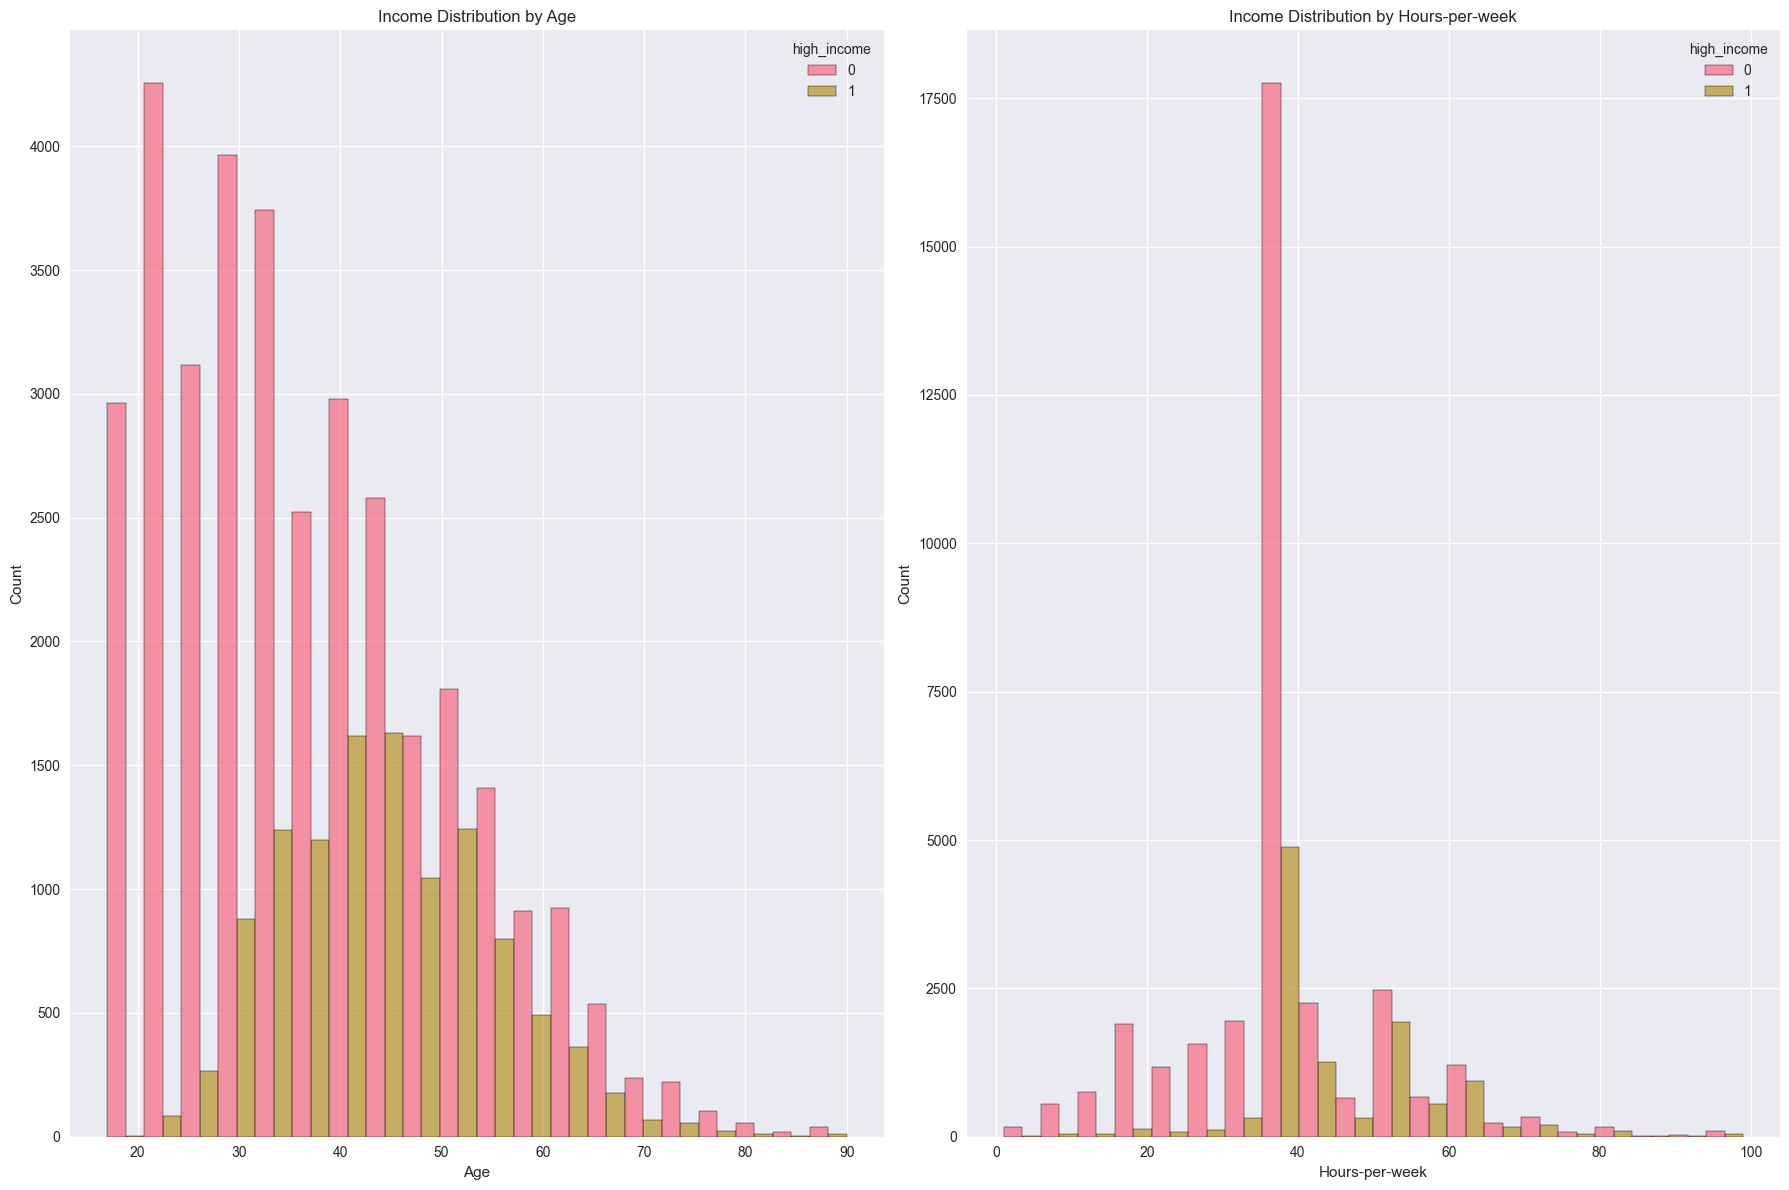

In [69]:
#Create basic plots for income distribution across all variables: Numerical Variables
fig, axes = plt.subplots(1, 2, figsize = (18, 12))

sns.histplot(data=df_clean, x='age', hue='high_income', bins=20, multiple='dodge', ax = axes[0])
axes[0].set_title("Income Distribution by Age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

sns.histplot(data=df_clean, x='hours-per-week', hue='high_income', bins=20, multiple='dodge', ax = axes[1])
axes[1].set_title("Income Distribution by Hours-per-week")
axes[1].set_xlabel("Hours-per-week")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

**Key Observation:**
- **Income Distribution by Age:**
  - Ages between 40 to 50 yrs have the highest count of high income individuals.
  - Ages below and between 20 to 40 have the highest count of low income individuals.
  - Ages 30 and below and 60 and above have the lowest count of high income individuals.
  - Ages above 60 have the lowest count of low income indidvidual.
- **Income Distribution by Hours-per-week:**
  - Individuals who work approximately near 40 hours per week have the highest count of low income individuals.
  - Individuals who work approximately near 40 and greater uptil 60 hours per week have the highest count of high income individuals. 

**Briefly describe patterns and data quality issues:**
- Sudden or drastic increase of value of counts which can be seen from the plots made earlier.
- Too many categorical variables to consider which creates somehow redundancy and also confusion on which columns are necessary and important for the model
- Distribution of variables are not normalize accross different features present within the dataset. 

**2.) Train-Test Split**
- 

In [70]:
#Drop non-numerical features or columns:
df_clean = df_clean.select_dtypes(include = ['number'])
numerical_cols = " | ".join(df_clean.columns.tolist())
num_cols = len(df_clean.columns.tolist())

print("Total number of columns or features:", num_cols)
print("=" * 60)
print(numerical_cols)

Total number of columns or features: 98
age | fnlwgt | education-num | capital-gain | capital-loss | hours-per-week | high_income | WC_Local-gov | WC_Never-worked | WC_Private | WC_Self-emp-inc | WC_Self-emp-not-inc | WC_State-gov | WC_Without-pay | EDUC_11th | EDUC_12th | EDUC_1st-4th | EDUC_5th-6th | EDUC_7th-8th | EDUC_9th | EDUC_Assoc-acdm | EDUC_Assoc-voc | EDUC_Bachelors | EDUC_Doctorate | EDUC_HS-grad | EDUC_Masters | EDUC_Preschool | EDUC_Prof-school | EDUC_Some-college | MS_Married-AF-spouse | MS_Married-civ-spouse | MS_Married-spouse-absent | MS_Never-married | MS_Separated | MS_Widowed | OCC_Armed-Forces | OCC_Craft-repair | OCC_Exec-managerial | OCC_Farming-fishing | OCC_Handlers-cleaners | OCC_Machine-op-inspct | OCC_Other-service | OCC_Priv-house-serv | OCC_Prof-specialty | OCC_Protective-serv | OCC_Sales | OCC_Tech-support | OCC_Transport-moving | REL_Not-in-family | REL_Other-relative | REL_Own-child | REL_Unmarried | REL_Wife | RCE_Asian-Pac-Islander | RCE_Black | RCE_

**Key Application"**
- This method allows us to select only numerical columns or features to be use.
- Our model and also the library scikit-learn requires all columns or features must be in numerical form or type.
- All columns mentioned above are numerical columns or features that the model will be using. 

In [71]:
#Prepare your feature (X) and target variable (y)
X = df_clean.drop('high_income', axis = 1)
y = df_clean['high_income']

**Key Application:**
- For the features that will be utilized is that we will be using all columns except the target variable which is 'high_income'.

In [72]:
#Split dataframe to test and train sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

**Key Application:**
- We split the data to test and train sets and equate the test size to 0.2 where 80% of the data will be used to train the model and the remaining 20% for testing.
- We set random state to 42 for as it is the default setting for the majority of cases that we split data to test and train sets.
- Lastly, we set stratify to (y) to ensure equality in proportions for the test and train sets. 

In [73]:
#Verfication of distribution of test and train sets:
full_dataset = y.mean()
train_set = y_train.mean()
test_set = y_test.mean()

print("=" * 60)
print(f"{'Verification of Distribution of Target Variable':^60}")
print("=" * 60)
print("Full dataset = ", f"{full_dataset:.4f}")
print("Train set =", f"{train_set:.4f}")
print("Test set = ", f"{test_set:.4f}")

      Verification of Distribution of Target Variable       
Full dataset =  0.2478
Train set = 0.2478
Test set =  0.2479


**Key Application:**
- This method ensures that the distribution of target variable are equal in all sides. 

**3.) Fit the LPM**
- 

In [74]:
#Add constant term for intercept (required by statsmodels):
X_train_cons = sm.add_constant(X_train)
X_test_cons = sm.add_constant(X_test)

In [75]:
#Fitting of LPM model using OLS:
LPM_model = sm.OLS(y_train, X_train_cons)
LPM_result = LPM_model.fit()

In [76]:
#Full model summary:
LPM_model_summary = LPM_result.summary()

print("=" * 78)
print(f"{'Linear Probability Model Summary':^78}")
print("=" * 78)
print(LPM_model_summary)

                       Linear Probability Model Summary                       
                            OLS Regression Results                            
Dep. Variable:            high_income   R-squared:                       0.370
Model:                            OLS   Adj. R-squared:                  0.369
Method:                 Least Squares   F-statistic:                     223.3
Date:                Fri, 06 Feb 2026   Prob (F-statistic):               0.00
Time:                        22:16:35   Log-Likelihood:                -12583.
No. Observations:               36177   AIC:                         2.536e+04
Df Residuals:                   36081   BIC:                         2.617e+04
Df Model:                          95                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

**Key Observation and Application:**
- We applied LPM via the use of the OLS() function from the scikit-learn library.
- Created the model and also fitted the needed parameters for the model.
- Displayed the model summary base from the results of the model. 

**4.) Model Summary Interpretation**
- 

In [77]:
#Columns that violated the p-value rule where p-value must not be exceed 0.05 or p <= 0.05:
alpha = 0.05
insignificant_cols_1 = LPM_result.pvalues[LPM_result.pvalues > alpha].index.tolist()
insignificant_cols_2 = " | ".join(insignificant_cols_1)
inc_num_cols = len(insignificant_cols_1)

print("Total number of columns or features that are insignificant:", inc_num_cols)
print("=" * 62)
print(insignificant_cols_2)

Total number of columns or features that are insignificant: 40
WC_Never-worked | EDUC_11th | EDUC_12th | EDUC_7th-8th | EDUC_9th | EDUC_Bachelors | EDUC_Some-college | MS_Married-AF-spouse | MS_Never-married | MS_Widowed | OCC_Armed-Forces | OCC_Craft-repair | OCC_Priv-house-serv | RCE_Black | RCE_Other | NC_Canada | NC_Ecuador | NC_El-Salvador | NC_England | NC_France | NC_Germany | NC_Greece | NC_Guatemala | NC_Haiti | NC_Holand-Netherlands | NC_Honduras | NC_Hong | NC_Hungary | NC_India | NC_Iran | NC_Ireland | NC_Italy | NC_Jamaica | NC_Japan | NC_Laos | NC_Outlying-US(Guam-USVI-etc) | NC_Philippines | NC_Portugal | NC_United-States | NC_Yugoslavia


**Key Observation:**
- The following columns or features seen above violated the p-value criteria where p-values must be less than or equal to 0.05
- These column or features are deemed insignificant for the model and must be dropped or remove from the dataset. 

In [78]:
#Columns that did not violate the p-value rule where p-value must not be exceed 0.05 or p <= 0.05:
alpha = 0.05
significant_cols_1 = LPM_result.pvalues[LPM_result.pvalues <= alpha].index.tolist()
significant_cols_2 = " | ".join(significant_cols_1)
ic_num_cols = len(significant_cols_1)

print("Total number of columns or features that are significant:", ic_num_cols)
print("=" * 60)
print(significant_cols_2)

Total number of columns or features that are significant: 58
const | age | fnlwgt | education-num | capital-gain | capital-loss | hours-per-week | WC_Local-gov | WC_Private | WC_Self-emp-inc | WC_Self-emp-not-inc | WC_State-gov | WC_Without-pay | EDUC_1st-4th | EDUC_5th-6th | EDUC_Assoc-acdm | EDUC_Assoc-voc | EDUC_Doctorate | EDUC_HS-grad | EDUC_Masters | EDUC_Preschool | EDUC_Prof-school | MS_Married-civ-spouse | MS_Married-spouse-absent | MS_Separated | OCC_Exec-managerial | OCC_Farming-fishing | OCC_Handlers-cleaners | OCC_Machine-op-inspct | OCC_Other-service | OCC_Prof-specialty | OCC_Protective-serv | OCC_Sales | OCC_Tech-support | OCC_Transport-moving | REL_Not-in-family | REL_Other-relative | REL_Own-child | REL_Unmarried | REL_Wife | RCE_Asian-Pac-Islander | RCE_White | SX_Male | NC_China | NC_Columbia | NC_Cuba | NC_Dominican-Republic | NC_Mexico | NC_Nicaragua | NC_Peru | NC_Poland | NC_Puerto-Rico | NC_Scotland | NC_South | NC_Taiwan | NC_Thailand | NC_Trinadad&Tobago | NC

**Key Observation:**
- The following columns or features seen above did not violate the p-value criteria where p-values must be less than or equal to 0.05.
- These should be retain and use for the tuned model to determine if there are any changes in the model summary. 

**Important Key Observations from the Model Summary:**
- **R-Squared:** 0.370
  - 37% of the data is explained by the predictors and the model.
  - R^2 is at its lowest end and it is not and ideal result.
  - This is caused by either removing significant variables, adding random data, outliers and other factors that may affect our R^2 value.
- **Adjusted R-squared:** 0.369
  - Close and approximately the same value as the R^2.
  - 36.9% means that there's too much noise or uneccessary data in the dataset that does not contribute or help the model predict.
  - Lower adjusted R^2 means that the model penalizes us for using top many features or columns that are deemed uneccesary.
- **F-Statistics:** 223.3
  - This means that our independent variables are doing a batter job of predicting our target variable compared to using 0 predictions in a model.
  - Having a high F-statistics means that our variable collectively provide more informations which aids our model.
- **Prob (F-statistic):** 0.00
  - Meets the p-value criteria where it should be less than or equal to 0.05. 
  - The model is better than guessing the target variable.
  - This means that the model is statistically significant.
- **Log-Likelihood:** -12583.
  - This tells us that the parameters of the model does not fit well the data provided.
  - This model has a low (more negative) likelihood.
  - The value is far-away from the ideal value of Log-likelihood which it should be close to 0.
- **AIC:** 2.536e+04 **&** **BIC:** 2.617e+04
  - Both AIC and BIC values are not ideal due to that there are large values. The lower the better.
  - Large value of AIC means that there is so much information loss due to the sheer number of features that have been fitted to the model. 
  - Large value of BIC applies the same concept as AIC but stricter in penalizing if there are to many variables.
- **In conclusion:**
  - The model did poorly based from the given important key information from the model summary. 

**5.) Classification Metrics**
- 

In [79]:
#Convert predicted values to class predictions using a 0.5 threshold:
y_pred_prob = LPM_result.predict(X_test_cons)
y_pred_class = (y_pred_prob >= 0.5).astype(int)

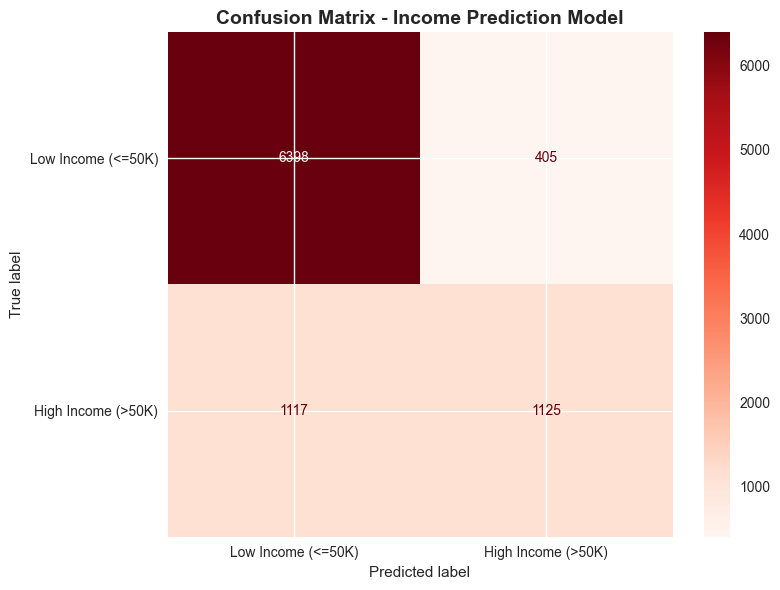

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      6803
           1       0.74      0.50      0.60      2242

    accuracy                           0.83      9045
   macro avg       0.79      0.72      0.75      9045
weighted avg       0.82      0.83      0.82      9045



In [80]:
#Create a confusion matrix:
conf_matrix = confusion_matrix(y_test, y_pred_class)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Low Income (<=50K)', 'High Income (>50K)'])
disp.plot(cmap='Reds', ax=ax, values_format='d')
ax.set_title('Confusion Matrix - Income Prediction Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=" * 60)
print("Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_class))

In [81]:
#Compute and interpret: Accuracy, Recall (Sensitivity), Specificity, F1-score:
accuracy = accuracy_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class) 
precision = precision_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)
TN, FP, FN, TP = conf_matrix.ravel()
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

print("=" * 60)
print("Model Performance Metrics:")
print("=" * 60)
print(f"Accuracy: {accuracy:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Precision: {precision:.3f}")
print(f"F1-Score: {f1:.3f}")

Model Performance Metrics:
Accuracy: 0.832
Recall (Sensitivity): 0.502
Specificity: 0.940
Precision: 0.735
F1-Score: 0.597


**Explain what each metric means for this income prediction task:**
- **Accuracy:** 0.832
  - 83.2% of all predictions are correct. 
  - Good overall measure but can be misleading if class imbalance.
- **Recall (Sensitivity):** 0.502
  - 50.2% of actual high-income people were correctly identified.
- **Specificity:** 0.940
  - 94% of actual low-income people were correctly identified.
- **Precision:** 0.735
  - 73.5% of predicted high-income people actually earn >$50K.
- **F1-Score:** 0.597
  - 59.7% - Balanced measure when both errors matter.
  - Good when false positives AND false negatives are costly. 